# What Makes a Good Book?

![bookstore](bookstore.jpg)

#### This project was done in January, 2026.

## 📖 The Background
Identifying popular products is incredibly important for e-commerce companies. Popular products generate more revenue and, therefore, play a key role in stock control.


## 💾 Dataset Summary
You've been asked to support an online bookstore by building a model to predict whether a book will be popular or not. They've supplied you with an extensive dataset (`"books.csv"`) containing information about all books they've sold, including:

* `title`
* `price`
* `review/helpfulness`
    - formatted as: the number of _helpful_ reviews / the total number of reviews
* `review/summary`
* `review/text`
* `descripion`
* `authors`
* `categories`
* `popularity` (target variable)


# Objectives
Build a model that predicts whether a book will be rated as popular or not.  
The bookstore has high expectations & have set a target of at least 70% accuracy. You are free to use as many features as you like, and will need to engineer new features to achieve this level of performance.

# Summary of Findings & Recommendations
This project utilizes machine learning techniques from the `sklearn` module to examine data from a bookstore regarding the books they've sold. More specifically, data transformation, some data engineering, & preprocessing were used to prepare data for classification models that evaluated whether a book will be rated as popular or not. The model was fine-tuned until a satisfactory accuracy score of at least 70% was achieved.

In this project, there were two main sections.


### Analysis I - Exploratory Data Analysis, Cleaning
The dataset was imported & evaluated to determine what preprocessing steps, if any, were necessary before thorough analyses could be done. Of the nine variables, only one had one missing value (there were 15,719 data points in the dataset). This missing data point was replaced with an empty string.

A general evaluation of the primary variable of interest ('popularity') was conducted. Of the 15,719 reviews of the books sold by this bookstore, 10,490 labeled a book "Unpopular" & 5,229 labeled a book "Popular"; about a 2:1 ratio.

Additional preprocessing steps were employed to enhance the quality of the data. The 'review/helpfulness' variable was split into two to indicate more clearly the number of helpful reviews & total reviews of a book. A new feature was made calculating the percentage of helpful reviews there were for each book. The cases of book 'categories' were also standardized to ensure consistency.


### Analysis II - Modeling
Before building the models, the cleaned data was preprocessed to further enhance the feature variables & their contributions to the modeling process. More specifically, the 'categories' variable was encoded into binary, numerical variables so that they can be utilized in the modeling process. To combat overfitting, categories with at least 21 books sold were included which lessened the number of categories from 60 to 56.  
Additionally, count vectorizers were used to determine how often different words were contained in readers' reviews (the 'review/summary' & 'review/text' variables). These vectorizers were transformed into numerical frequency variables, allowing them to be used as feature variables for the modeling process. Specific words likely to be associated with reviews of popular books were defined & used to create these data points.

Of the newly transformed data, the following variables were used as feature variables: 'price', '# helpful reviews', '# reviews', '% helpful reviews', the 56 most popular 'categories', 'pos_words_summary', 'pos_words_text', & 'pos_words_desc' (the latter three spawned from the 'review/summary', 'review/text', & 'description' variables).  
A random forest classifier was used to model the data & cast binary predictions. Moreover, a random search cross-validation was employed to find optimal hyperparameter values in terms of raising the model's predictive accuracy. The hyperparameters included: 'n_estimators', 'max_depth', & 'min_samples_split'. Their optimal values can be referenced in **Analysis II**.

> Ultimately, these feature variables & hyperparameter values yielded a model with an accuracy score of about 70.3%.

Following the modeling process, the feature variables were analyzed to determine which were the most important in terms of predicting whether books were deemed popular or not.  
Of the 63 feature variables utilized in the model, 56 of which refer to book categories, the book **price** is by far the most important feature when it comes to predicting whether books were labeled as popular or not. Five other variables have a relatively notable importance:
- **'pos_words_text'** - The number of positive words in a reader's full review.
- **'# reviews'** - The number of total reviews published of a book.
- **'% helpful reviews'** - The percentage of reviews of a book deemed helpful.
- **'pos_words_desc'** - The number of positive words in a book's description.
- **'# helpful reviews'** - The number of helpful reviews published of a book.

These six variables indicate that the price of a book, the number of reviews (both total & helpful), full text reviews, & book descriptions were the most important features in this prediction process. Most notably, the price is three times more important than any other feature. Some additional notes regarding the findings of the feature-importance analyses are listed below.
- The number of total reviews of a book is slightly more important than the number of helpful reviews.
- The full reviews written by readers are considerably more important than their review summaries (more than four times).
- The ten most important book categories, from most to least, are: Fiction, Religion, Biography & Autobiography, Business & Economics, History, Juvenile Fiction, Computers, Family & Relationship, Health & Fitness, & Cooking.



#### Recommendations
To achieve a model that achieves the desired predictive capabilities, a random forest classifier can be used with the aforementioned hyperparameter values & feature variables.

Of course, the model could possibly be optimized beyond this. Further experimentation could explore alternative machine learning algorithms, different interpretations & implementations of the text variables, & different sets of feature variables to try & elevate the model's predictive capabilities.  
On another note, by continuing to obtain & sell books, thus compiling more data, it can help contribute towards building more powerful predictive models that are more flexible & accurate in evaluating whether books will be labeled as popular or not.

Ultimately, a bookstore will naturally be interested in obtaining popular books because they are easier to sell to customers. By utilizing such modeling processes, the bookstore can more easily find characteristics & trends of books that are more likely to be associated with "popular" books. By obtaining such books, the bookstore can potentially become more efficient in their sales because customers are naturally more interested in more appealing products. The more sales the bookstore experiences, the more they will drive up important business metrics like purchases & revenue, popularity, competitiveness/relevance/recognition, flexibility, & additional measures of success.

Furthermore, for a business like a bookstore, identifying popular products will be very beneficial when it comes to stock management & areas such as inventory tracking & demand forecasting. For example, identifying the most popular book categories will help the bookstore gauge how often they need to resupply their inventories across these categories in addition to projecting how many books might be sold, thus giving them an impression & reasonable goals as to potential ranges of sales in the future (e.g. monthly, quarterly, annually).

Such characteristics in particular, based on books that have been sold by the bookstore, can be referenced above or in the **Analysis II - Feature Variable Analysis** section.
- In short, the model produced concluded that the price of a book, the full reviews of readers, the total number of reviews, the book description, & the number of helpful reviews were the most important in terms of identifying popular books. Among the various book categories, Fiction, Religion, Biography & Autobiography, Business & Economics, & History books were found to be the most important.

-----------------------------------------------------------------------------------------------------------------------------
-----------------------------------------------------------------------------------------------------------------------------
-----------------------------------------------------------------------------------------------------------------------------

# Import packages, data

In [27]:
#import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Analysis I - Exploratory Data Analysis, Cleaning
After importing the data, it should be evaluated to check for inconsistencies & to get a basic understanding of the many variables. This should give an idea as to what kind of preprocessing steps need to be taken to prepare the data for more extensive, valid analyses.

In [28]:
#import data
orig_df = pd.read_csv("books.csv")

#inspect data
display(orig_df.head(3))
display(orig_df.info())

,title,price,review/helpfulness,review/summary,review/text,description,authors,categories,popularity
0,We Band of Angels: The Untold Story of America...,10.88,2/3,A Great Book about women in WWII,I have alway been a fan of fiction books set i...,"In the fall of 1941, the Philippines was a gar...",'Elizabeth Norman','History',Unpopular
1,Prayer That Brings Revival: Interceding for Go...,9.35,0/0,Very helpful book for church prayer groups and...,Very helpful book to give you a better prayer ...,"In Prayer That Brings Revival, best-selling au...",'Yong-gi Cho','Religion',Unpopular
2,The Mystical Journey from Jesus to Christ,24.95,17/19,Universal Spiritual Awakening Guide With Some ...,The message of this book is to find yourself a...,THE MYSTICAL JOURNEY FROM JESUS TO CHRIST Disc...,'Muata Ashby',"'Body, Mind & Spirit'",Unpopular


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15719 entries, 0 to 15718
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               15719 non-null  object 
 1   price               15719 non-null  float64
 2   review/helpfulness  15719 non-null  object 
 3   review/summary      15718 non-null  object 
 4   review/text         15719 non-null  object 
 5   description         15719 non-null  object 
 6   authors             15719 non-null  object 
 7   categories          15719 non-null  object 
 8   popularity          15719 non-null  object 
dtypes: float64(1), object(8)
memory usage: 1.1+ MB


None

In this dataset, there are 9 variables & 15,719 data points. Fortunately, there is only one missing data point (in the 'review/summary' variable). The variables of the dataset are fairly self explanatory, but the 'review/helpfulness' column has values that aren't easy to analyze & compare across data points. Generally, they are formatted as: [integer]/[integer]; e.g. 0/0, 17/19, the latter integer is always greater than or equal to the former. It is presumed that these values denote the number of _helpful_ reviews / the number of total reviews. It might be better if this variable was redone to be more interpretable. For example, they could be split, & another column could be made indicating what is the percentage of total reviews that were helpful.

Regarding the one missing value, imputing a variable designed to record user input through text messages, this is not something that can be imputed. Given that the missingness only accounts for one data point, it is reasonable to exclude it from analyses.

The target variable ('popularity') has two values--"Popular" & "Unpopular". There are several categorical variables that will have to be encoded to numerical values if they are to be used in the modeling process. Of the variables, the following will likely be used as feature variables: 'price', 'review/helpfulness', 'review/summary', 'review/text', 'description', 'categories'. Given that each book's title is unique, it will likely be excluded.

In [29]:
#Explore the data

#orig_df[orig_df.isna().any(axis=1)]
#orig_df.sample(5)
#orig_df['title'].value_counts()
#orig_df['categories'].value_counts()
orig_df['popularity'].value_counts()

popularity
Unpopular    10490
Popular       5229
Name: count, dtype: int64

Notes from EDA:
- There are 6,985 unique books. The most reviewed book, "Eldest (Inheritance, Book 2)," has 90 reviews.
- There are 6,447 authors, implying that some wrote multiple books that are in this dataset.
- Of the 15,719 reviews, 10,490 of them were labelled as "Unpopular" & 5,229 were labelled as "Popular"; about a 2:1 ratio.
- There are 313 unique book categories. There are also some inconsistencies in this variable; "Fiction", "FICTION".


### Analysis I - Preprocessing
Prior to generating the model, the data needs some preprocessing in order for machine learning algorithms to be applied. The main step involves encoding the many categorical variables to numerical values. Additionally, a couple of variables need to be cleaned up including the 'review/helpfulness' variable.
- Typically, the values in this variable are separated by a slash ("/"). The first number indicates the number of _helpful_ reviews, whereas the second number indicates the total number of reviews. As such, the first number never exceeds the second.

In [30]:
#Create a copy of the original data
df_cleaning_I = orig_df.copy()

#Clean up the 'review/helpfulness' column
df_cleaning_I[['# helpful reviews','# reviews']] = df_cleaning_I['review/helpfulness'].str.split('/', expand=True).astype('int')

#Calculate the % of reviews that were helpful
    #for rows w/0 reviews, dividing 0/0 outputs "null" --> fill missing values with 0
df_cleaning_I['% helpful reviews'] = (df_cleaning_I['# helpful reviews'] / df_cleaning_I['# reviews']).fillna(0)

#Remove original 'review/helpfulness' column
df_cleaning_I.drop(columns=['review/helpfulness'], inplace=True)
display(df_cleaning_I.sample(3))

,title,price,review/summary,review/text,description,authors,categories,popularity,# helpful reviews,# reviews,% helpful reviews
1512,Things You Need To Be Told,14.00,Waste of paper; recycling the found copy I have.,"I found this book in a housemate house, someon...",Are good manners relevant in this day and age?...,"'Lesley Carlin', 'Honore McDonough Ervin', 'Et...",'Humor',Unpopular,0,0,0.0
14959,"A Search of African American Life, Achievement...",14.95,An excellent resource especially for grade-sch...,"A Search Of African American Life, Achievement...","Reviews the accomplishments, courage and strug...",'John C. Cothran','Social Science',Popular,0,0,0.0
4142,The Best-Kept Secret,10.07,Good,"This book was good, I recommend it to anyone w...",In this steamy thriller from #1 New York Times...,'Sandra Brown','Fiction',Unpopular,0,0,0.0


With the 'categories' variable, it should first be cleaned up in terms of capitaization. This reduced the number of unique categories from 313 to 304. Next, a lot of these categories account for very few books each. For example, only 34 categories account for at least 100 books each, & 243 categories account for less than 10 books each.  
This variable, given that it is non-numerical, will also have to be encoded. In adding so many additional columns, it could produce a model that has a tendency to overfit. As such, lessening the number of unique categories might help produce a more accurate model, which is one of the primary goals in this project.  
As a result, categories with at least ten books were included. This reduced the number of categories from 304 to 60 & the number of data points from 15,719 to 15,157, preserving a significant majority of the data points.
- **NOTE after performing initial modeling**: After initially performing the modeling process, more categories needed to be excluded in order to obtain a desirable accuracy score. As such, the threshold was altered to use categories with more than 20 books. This reduced the number of categories from 60 to 56 & the number of data points from 15,157 to 15,102. Fortunately, this only excluded 617 data points from the dataset (~ 3.9%).

In [31]:
#Fix capitalization inconsistencies in 'categories' column
df_cleaning_I['categories'] = df_cleaning_I['categories'].str.title()

#Exclude categories with < 20 books each
df_cleaning_I = df_cleaning_I.groupby('categories').filter(lambda x: len(x) > 20)
display(df_cleaning_I['categories'].nunique())

#Encode the categories to numerical values
categories = pd.get_dummies(df_cleaning_I['categories'], drop_first=True)
#attach the encoded columns to the main data, remove the original 'categories' variable
df_cleaning_II = pd.concat([df_cleaning_I, categories], axis=1)
df_cleaning_II.drop(columns=['categories'], inplace=True)

#display(df_cleaning_II.info())
display(df_cleaning_II.sample(3))

56

,title,price,review/summary,review/text,description,authors,popularity,# helpful reviews,# reviews,% helpful reviews,...,'Science','Self-Help','Social Science','Sports & Recreation','Study Aids','Technology & Engineering','Transportation','Travel','True Crime','Young Adult Fiction'
1084,Left to Tell: Discovering God Amidst The Rwand...,17.48,The World Should Never Forget,The Rwandan genocide happened 17-years ago. Bu...,Immaculee Ilibagiza grew up in a country she l...,'Immaculee Ilibagiza',Unpopular,1,1,1.000000,...,False,False,False,False,False,False,False,False,False,False
5163,Wars of the Irish Kings: A Thousand Years of S...,17.15,I'm not impressed,Wars of the Irish Kings: A Thousand Years of S...,"For the first thousand years of its history, I...",'David W. McCullough',Unpopular,1,18,0.055556,...,False,False,False,False,False,False,False,False,False,False
15020,Dracula Doesn't Drink Lemonade (Turtleback Sch...,14.75,dracula doesn't drink lemonade,you won't be laughing when count dracula nibbl...,There are some pretty weird grown-ups living i...,"'Debbie Dadey', 'Marcia Thornton Jones'",Popular,1,1,1.000000,...,False,False,False,False,False,False,False,False,False,False


# Analysis II - Modeling
With sufficient data cleaning now completed, the next step involves encoding the non-numerical variables that will be used as feature variables in the modeling process. For variables that contain excerpts of text of varying lengths, such as 'review/summary' & 'review/text', one way to utilize them in predictive modeling is to create a matrix of pieces of text similar to one-hot encoding for categorical variables. Columns will designate words found within all of the text values from the original variable, then the values will indicate how many times those words are present in that data point. For example, in a data point in the 'description' column, if the word "first" is present five times, then the cell in this hypothetical matrix will equate to 5.

The `CountVectorizer()` function from `sklearn` is capable of this. It compiles the words (or tokens) in variables with text & determines how many times each word is present in a data point. Moreover, this function can take specific inputted words to look for & include in the resulting matrix. This is relevant here because certain words may be more indicative of a popular or unpopular book. For example, in a review of a popular book, someone may utilize words like "perfect," "wonderful," "excellent," whereas unpopular books might include words like "boring," "unpleasant," or "uninteresting."

To make sure that words are not overcounted, ensuring data consistency will help. More specifically, the words should have consistent capitalization. As to what words should be included here, they can be compiled in a variety of ways. In this case, about a couple dozen words were compiled & used that are indicative of positive reviews that might be associated with reviews of a "popular" book. These words are available in the `pos_words` variable.

In [32]:
#Apply capitalization to words across text variables to ensure consistency
for col in ['review/summary','review/text','description']:
    df_cleaning_II[col] = df_cleaning_II[col].str.lower()

#Compile words likely associated with reviews of "popular" books
pos_words = ["amazing", "beautiful", "brilliant", "enjoy", "excellent", "exceptional", "fantastic", "good",
             "great", "helpful", "impressive", "incredible", "interesting", "like", "love", "outstanding",
             "perfect", "positive", "remarkable", "thrilling", "useful", "wonderful"]

In [33]:
#Instantiate a CountVectorizer
vectorizer = CountVectorizer(vocabulary = pos_words)

#Fit, transform 'review/summary', 'review/text', 'description'
rev_sum_transformed = vectorizer.fit_transform(df_cleaning_II['review/summary'].fillna(''))
rev_text_transformed = vectorizer.fit_transform(df_cleaning_II['review/text'])
desc_transformed = vectorizer.fit_transform(df_cleaning_II['description'])

#obtain counts of pos_words from 'review/summary', 'review/text', 'description'
df_cleaning_III = df_cleaning_II.copy()
df_cleaning_III['pos_words_summary'] = rev_sum_transformed.sum(axis=1).reshape(-1,1)
df_cleaning_III['pos_words_text'] = rev_text_transformed.sum(axis=1).reshape(-1,1)
df_cleaning_III['pos_words_desc'] = desc_transformed.sum(axis=1).reshape(-1,1)

#remove original columns
df_cleaning_III.drop(columns=['review/summary', 'review/text', 'description'], inplace=True)

display(df_cleaning_III.info())

<class 'pandas.core.frame.DataFrame'>
Index: 15102 entries, 0 to 15718
Data columns (total 65 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   title                          15102 non-null  object 
 1   price                          15102 non-null  float64
 2   authors                        15102 non-null  object 
 3   popularity                     15102 non-null  object 
 4   # helpful reviews              15102 non-null  int32  
 5   # reviews                      15102 non-null  int32  
 6   % helpful reviews              15102 non-null  float64
 7   'Architecture'                 15102 non-null  bool   
 8   'Art'                          15102 non-null  bool   
 9   'Bibles'                       15102 non-null  bool   
 10  'Biography & Autobiography'    15102 non-null  bool   
 11  'Body, Mind & Spirit'          15102 non-null  bool   
 12  'Books And Reading'            15102 non-null  bool

None

Now that the data has been preprocessed appropriately, it can be used for modeling. The variables not being used as feature variables ('title', 'author') should be removed.

Given the nature of the target variable, complexity of this task, & the dataset, a random forest classification algorithm was utilized. A random search cross-validation was also utilized to optimize the final model through the tuning some hyperparameters. A ratio of 75:25 was used when splitting the training & testing datasets, the latter of which will be used to evaluate the predictive capabilities of the model.
- Since the the dataset is imbalanced, particularly in terms of the frequencies of book categories ('category'), it will help to apply weights to counter such imbalances. To do so, the `class_weight` argumnt in `RandomForestClassifier()` can be set to "balanced".
- **NOTE** that the cell employing the cross validation can take several minutes to execute.

In [34]:
#Assign the feature/predictor variables. Remove irrelevant feature variables
X = df_cleaning_III.drop(columns=['title','authors','popularity']).values
y = df_cleaning_III['popularity'].values.reshape(-1,1)

#Split data into training/testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20)

**NOTE** that the cell below can take several minutes to execute.

In [35]:
#generate hyperparameter values to trial
params = {'n_estimators':np.arange(100,201,20), 'max_depth':np.arange(10,101,10), 'min_samples_split':np.arange(2,6,1)}

#instantiate the classifier
rf_raw = RandomForestClassifier(class_weight="balanced", random_state=20)

#perform a 5-fold random-search cross validation
rand_CV = RandomizedSearchCV(rf_raw, param_distributions=params, cv=5, random_state=20)

#fit the CV to the data
    #.ravel() is used to flatten arrays
rand_CV.fit(X_train, y_train.ravel())

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=20),
                   param_distributions={'max_depth': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100]),
                                        'min_samples_split': array([2, 3, 4, 5]),
                                        'n_estimators': array([100, 120, 140, 160, 180, 200])},
                   random_state=20)

In [36]:
#Retrieve the best hyperparameter values
hyp_params = rand_CV.best_params_
display(hyp_params)

{'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 60}

With a five-fold random-search cross validation, the optimal hyperparameters values are:
- `n_estimators` = 100
- `max_depth` = 60
- `min_samples_split` = 2

These values will be used to create the final random forest model.

In [37]:
#Create the random forest model using the optimal hyperparameter values
rf = RandomForestClassifier(n_estimators=hyp_params['n_estimators'], max_depth=hyp_params['max_depth'], 
                            min_samples_split=hyp_params['min_samples_split'], class_weight="balanced", random_state=42)

#Fit the data to the model. Flatten the target data from a 2D column into a 1D vector using .ravel().
rf.fit(X_train, y_train.ravel())

RandomForestClassifier(class_weight='balanced', max_depth=60, random_state=42)

In [38]:
#Evaluate model accuracy
display(rf.score(X_train, y_train))
display(rf.score(X_test, y_test))

model_accuracy = rf.score(X_test, y_test)

0.9862263817764436

0.703125

The model had an accuracy score of about 70.3% on the test data, accomplishing the 70% accuracy goal.

### Analysis II - Feature Variable Analysis
With a satisfactory model achieved, the feature variables involved can be examined to determine which were most important in finding popular books.

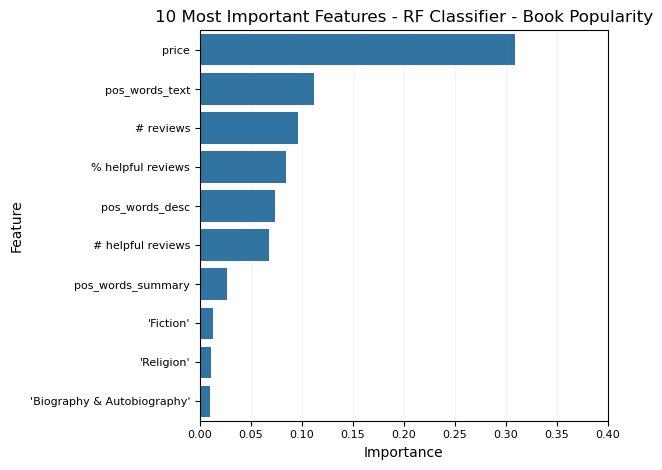

In [44]:
#Retrieve feature importances
feat_importances = rf.feature_importances_

#Put them into a DF
feat_importances_df = pd.DataFrame({'Feature': df_cleaning_III.drop(columns=['title','authors','popularity']).columns, 
                                    'Importance': feat_importances}).sort_values(
                                        'Importance', ascending=False).reset_index(drop=True)

#Visualize the 10 most important features
sns.barplot(data=feat_importances_df.nlargest(10, 'Importance'), x='Importance', y='Feature')
#edit plot details
plt.title('10 Most Important Features - RF Classifier - Book Popularity')
plt.xticks(ticks=np.arange(0,0.41,0.05), fontsize=8)
plt.yticks(fontsize=8)
plt.grid(axis='x', alpha=0.1,color='gray')
plt.tight_layout();

The plot above illustrates the top ten most important feature variables when it comes to accurately predicting whether books sold from the bookstore are labeled as popular or not. The model used was a random forest classifier. The dataset included about 15,100 data points.

Of the 63 feature variables utilized in the model, 56 of which refer to book categories, the book price is by far the most important feature (~ 0.31) when it comes to predicting whether books were labeled as popular or not. Five other variables have a relatively notable importance: 'pos_words_text' (~ 0.11), '# reviews' (~ 0.097), '% helpful reviews' (~ 0.085), 'pos_words_desc' (~ 0.074), & '# helpful reviews' (~ 0.067).  
These six variables indicate that the price of a book, the number of reviews (both total & helpful), full text reviews, & book descriptions were the most important features in this prediction process. Most notably, the price is three times more important than any other feature. Some additional notes are listed below.
- The number of total reviews of a book is slightly more important than the number of helpful reviews.
- The full reviews ('review/text' or 'pos_words_text', ~ 0.112) written by readers are considerably more important than their review summaries ('review/summary' or 'pos_words_summary', ~ 0.027) in terms of predicting whether a book will be popular or not (more than four times).

On another note, it would be useful to get an understanding as to what book categories were most insightful in this prediction process.

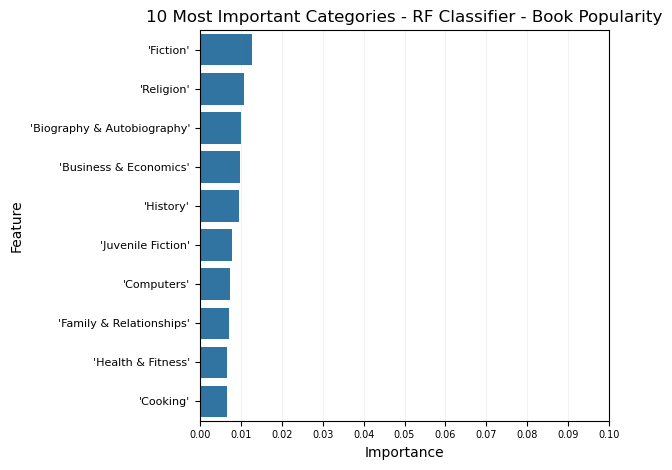

In [50]:
#Find most popular book categories
catg_feat_importances_df = feat_importances_df.iloc[7:17,:].reset_index(drop=True)

#Visualize them
sns.barplot(data=catg_feat_importances_df, x='Importance', y='Feature')
#edit plot details
plt.title('10 Most Important Categories - RF Classifier - Book Popularity')
plt.xticks(ticks=np.arange(0,0.11,0.01), fontsize=7)
plt.yticks(fontsize=8)
plt.grid(axis='x', alpha=0.1,color='gray')
plt.tight_layout();

The plot above illustrates the top ten most book categories when it comes to accurately predicting whether books sold from the bookstore are labeled as popular or not. The model used was a random forest classifier. The dataset included about 15,100 data points.  
For clarity, these ten categories were the 8th-17th most important feature variables outright in this prediction process; however, they all have a feature-importance metric between 0.006-0.013.

Based on this data, it can be used to determine which categories were essentially the most popular among the 56 included in this model. They include, from most to least important: Fiction, Religion, Biography & Autobiography, Business & Economics, History, Juvenile Fiction, Computers, Family & Relationship, Health & Fitness, & Cooking.

### Analysis II - Conclusions
Build a model that predicts whether a book will be rated as popular or not.  
The bookstore has high expectations & have set a target of at least 70% accuracy. You are free to use as many features as you like, and will need to engineer new features to achieve this level of performance.

Recall that this project aimed to build a model, with an accuracy of at least 70%, to predict whether a book will be rated as "popular" or not. Following preprocessing of the cleaned dataset, the 'review/summary', 'review/text', & 'description' variables were transformed into three new variables ('pos_words_summary', 'pos_words_text', 'pos_words_desc') indicating the total number of positive words found in a data point across each respective variable. These "positive" words were defined as those likely to be associated with reviews of popular books & they can be referenced in the `pos_words` variable. Additionally, the 'categories' variable was truncated to contain books amongst the most-popular categories (those with more than 20 books), which left 15,102 data points. In other words, binary columns were made for each column indicating whether a book was in a certain category or not.

As such, the variables used as feature variables included: 'price', '# helpful reviews', '# reviews', '% helpful reviews', the 56 'categories', 'pos_words_summary', 'pos_words_text', & 'pos_words_desc'.  
A random forest classifier was used to model the data & cast predictions. Moreover, a random search cross-validation was done to find optimal hyperparameter values in terms of raising the model's predictive accuracy. The hyperparameters included: 'n_estimators', 'max_depth', & 'min_samples_split'. These optimal values are listed below.
- 'n_estimators': 100
- 'max_depth': 60
- 'min_samples_split': 2

> Using these feature variables & hyperparameter values yielded a model with an accuracy score of about 70.3%.

With this model, the feature variables were evaluated to determine which were the most important in predicting whether a book was deemed popular or not.  
Of the 63 feature variables utilized in the model, 56 of which refer to book categories, the book price is by far the most important feature (~ 0.31) when it comes to predicting whether books were labeled as popular or not. Five other variables have a relatively notable importance: 'pos_words_text' (~ 0.11), '# reviews' (~ 0.097), '% helpful reviews' (~ 0.085), 'pos_words_desc' (~ 0.074), & '# helpful reviews' (~ 0.067).
These six variables indicate that the price of a book, the number of reviews (both total & helpful), full text reviews, & book descriptions were the most important features in this prediction process. Most notably, the price is three times more important than any other feature. Some additional notes regarding the findings of the feature-importance analyses are listed below.
- The number of total reviews of a book is slightly more important than the number of helpful reviews.
- The full reviews ('review/text' or 'pos_words_text') written by readers are considerably more important than their review summaries ('review/summary' or 'pos_words_summary') in terms of predicting whether a book will be popular or not (more than four times).
- When it comes to the most important categories, they are (from most to least): Fiction, Religion, Biography & Autobiography, Business & Economics, History, Juvenile Fiction, Computers, Family & Relationship, Health & Fitness, & Cooking.


#### Future Exploration
Further experimentation could explore alternative machine learning algorithms, different interpretations & implementations of the text variables, & different sets of feature variables to try & elevate the model's predictive capabilities.